In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor
from xgboost import plot_importance

In [79]:
CSV_PATH = "../../../Yahoo_Finance/Google/GOOG_historical_stock.csv"
 
df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.info())
print("Missing values per column:\n", df.isnull().sum())

         Date      Open      High       Low     Close  Adj Close     Volume
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.477291  897427216
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.674062  458857488
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.700973  366857939
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.589132  306396159
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.617030  184645512
<class 'pandas.DataFrame'>
RangeIndex: 5524 entries, 0 to 5523
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5524 non-null   str    
 1   Open       5524 non-null   float64
 2   High       5524 non-null   float64
 3   Low        5524 non-null   float64
 4   Close      5524 non-null   float64
 5   Adj Close  5524 non-null   float64
 6   Volume     5524 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 302.2 KB
None
Missing values per colum

In [80]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
 
df = df.dropna().reset_index(drop=True)
 
TARGET_COL = 'Close'
prices = df[[TARGET_COL]].values 
 
print(f"Data range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total trading days: {len(df)}")

Data range: 2004-08-19 00:00:00 to 2026-08-04 00:00:00
Total trading days: 5524


In [81]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

In [82]:
LOOKBACK = 3
HORIZON = 30

df['target'] = df['Close'].shift(-HORIZON)  # price 30 days ahead

for lag in range(1, LOOKBACK + 1):
    df[f'close_lag_{lag}'] = df['Close'].shift(lag)

df['rolling_mean_5'] = df['Close'].shift(1).rolling(5).mean()
df['rolling_std_5'] = df['Close'].shift(1).rolling(5).std()

df = df.dropna().reset_index(drop=True)

feature_cols = [f'close_lag_{i}' for i in range(1, LOOKBACK+1)] + ['rolling_mean_5', 'rolling_std_5']
X = df[feature_cols]
y = df['target']

In [83]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [84]:
# # Build the LSTM Model
# model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
#     Dropout(0.2),
#     LSTM(32, return_sequences=False),
#     Dropout(0.2),
#     Dense(16, activation='relu'),
#     Dense(1)  # predicted price 30 days ahead
# ])
 
# model.compile(optimizer='adam', loss='mean_squared_error')
# model.summary()

In [85]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    early_stopping_rounds=10,
    eval_metric='rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-rmse:159.82620
[1]	validation_0-rmse:155.70980
[2]	validation_0-rmse:151.82461
[3]	validation_0-rmse:148.12091
[4]	validation_0-rmse:144.62625
[5]	validation_0-rmse:141.30124
[6]	validation_0-rmse:138.16469
[7]	validation_0-rmse:135.20848
[8]	validation_0-rmse:132.42269
[9]	validation_0-rmse:129.79597
[10]	validation_0-rmse:127.30705
[11]	validation_0-rmse:124.99828
[12]	validation_0-rmse:122.81920
[13]	validation_0-rmse:120.77011
[14]	validation_0-rmse:118.83723
[15]	validation_0-rmse:116.99695
[16]	validation_0-rmse:115.24867
[17]	validation_0-rmse:113.58780
[18]	validation_0-rmse:112.04841
[19]	validation_0-rmse:110.57311
[20]	validation_0-rmse:109.20570
[21]	validation_0-rmse:107.89536
[22]	validation_0-rmse:106.68127
[23]	validation_0-rmse:105.51658
[24]	validation_0-rmse:104.43896
[25]	validation_0-rmse:103.41303
[26]	validation_0-rmse:102.43662
[27]	validation_0-rmse:101.54543
[28]	validation_0-rmse:100.69344
[29]	validation_0-rmse:99.89053
[30]	validation_0-rms

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [86]:
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
 
# history = model.fit(
#     X_train, y_train,
#     validation_split=0.1,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )
 
# # Plot training history
# plt.figure(figsize=(10, 5))
# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.title('Model Loss Over Time')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

In [87]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"RMSE: ${rmse:.2f}, MAE: ${mae:.2f}, MAPE: {mape:.2f}%")

RMSE: $86.41, MAE: $53.07, MAPE: 21.99%


In [88]:
# y_pred_scaled = model.predict(X_test)
# y_pred = scaler.inverse_transform(y_pred_scaled)
# y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
 
# rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
# mae = mean_absolute_error(y_test_actual, y_pred)
# mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
 
# print(f"RMSE: ${rmse:.2f}")
# print(f"MAE:  ${mae:.2f}")
# print(f"MAPE: {mape:.2f}%")
 
# # Plot predictions vs actual
# plt.figure(figsize=(12, 6))
# plt.plot(y_test_actual, label='Actual Price')
# plt.plot(y_pred, label='Predicted Price')
# plt.title(f'Google Stock: Actual vs Predicted (30 days ahead, {LOOKBACK}-day lookback)')
# plt.xlabel('Test Sample Index')
# plt.ylabel('Price ($)')
# plt.legend()
# plt.show()

In [89]:
final_model = XGBRegressor(
    n_estimators=model.best_iteration,
    max_depth=4,
    learning_rate=0.05
)
final_model.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [90]:
# model.fit(X, y, epochs=len(history.history['loss']), batch_size=16, verbose=1)

In [91]:
# import joblib
# import os

# os.makedirs("export", exist_ok=True)
# joblib.dump(final_model, "export/google_xgb_model.pkl")

In [92]:
# # used AI to export the model for the frontend
# os.makedirs("export", exist_ok=True)
 
# model.save("export/google_lstm_model.keras")
# joblib.dump(scaler, "export/price_scaler.pkl")
# print("Exported: export/google_lstm_model.keras, export/price_scaler.pkl")

In [93]:
 
# print(json.dumps(output_json, indent=2))
# print("\nExported files in ./export/:")
# print(" - google_lstm_model.keras  (the trained model)")
# print(" - price_scaler.pkl         (needed to un-scale future predictions)")
# print(" - latest_prediction.json   (ready-to-use output for the frontend)")

In [94]:
os.makedirs("export", exist_ok=True)
# joblib.dump(model, "export/google_xgb_model.pkl")
joblib.dump(final_model, "export/google_xgb_model.pkl")

['export/google_xgb_model.pkl']

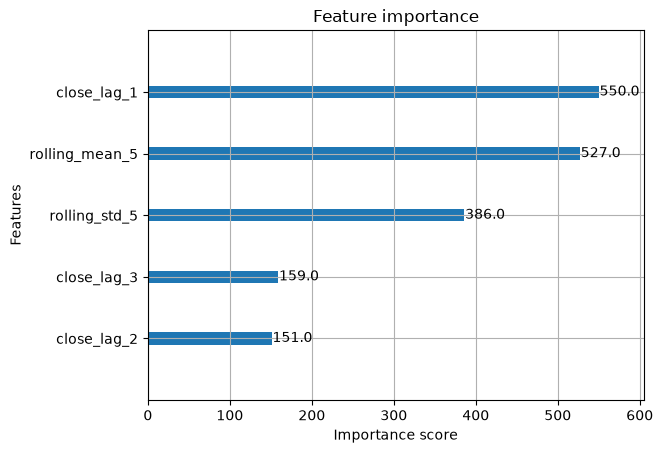

In [95]:

plot_importance(model)
plt.show()